# Stroke prediction usign _stroke-prediction-dataset_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df = df.dropna()

## Exploratory data analysis / visualization

In [9]:
numeric_cols = df.select_dtypes(include = "number").columns
object_cols = df.select_dtypes(include  = "object").columns

print("\t\tNumeric columns")
print("-"*50)

for col in numeric_cols:
    nunique = df[col].nunique()
    print(f"📌{col}:{nunique}")
    if nunique < 15:
        print("unique values: ",df[col].unique())

print("\t\n Object columns")
print("-"*50)

for col in object_cols:
    unique = df[col].nunique()
    print(f"📌{col}: {unique}")
    if nunique < 15:
        print("unique values: ",df[col].unique())

		Numeric columns
--------------------------------------------------
📌id:4909
📌age:104
📌hypertension:2
unique values:  [0 1]
📌heart_disease:2
unique values:  [1 0]
📌avg_glucose_level:3852
📌bmi:418
📌stroke:2
unique values:  [1 0]
	
 Object columns
--------------------------------------------------
📌gender: 3
unique values:  ['Male' 'Female' 'Other']
📌ever_married: 2
unique values:  ['Yes' 'No']
📌work_type: 5
unique values:  ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
📌Residence_type: 2
unique values:  ['Urban' 'Rural']
📌smoking_status: 4
unique values:  ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

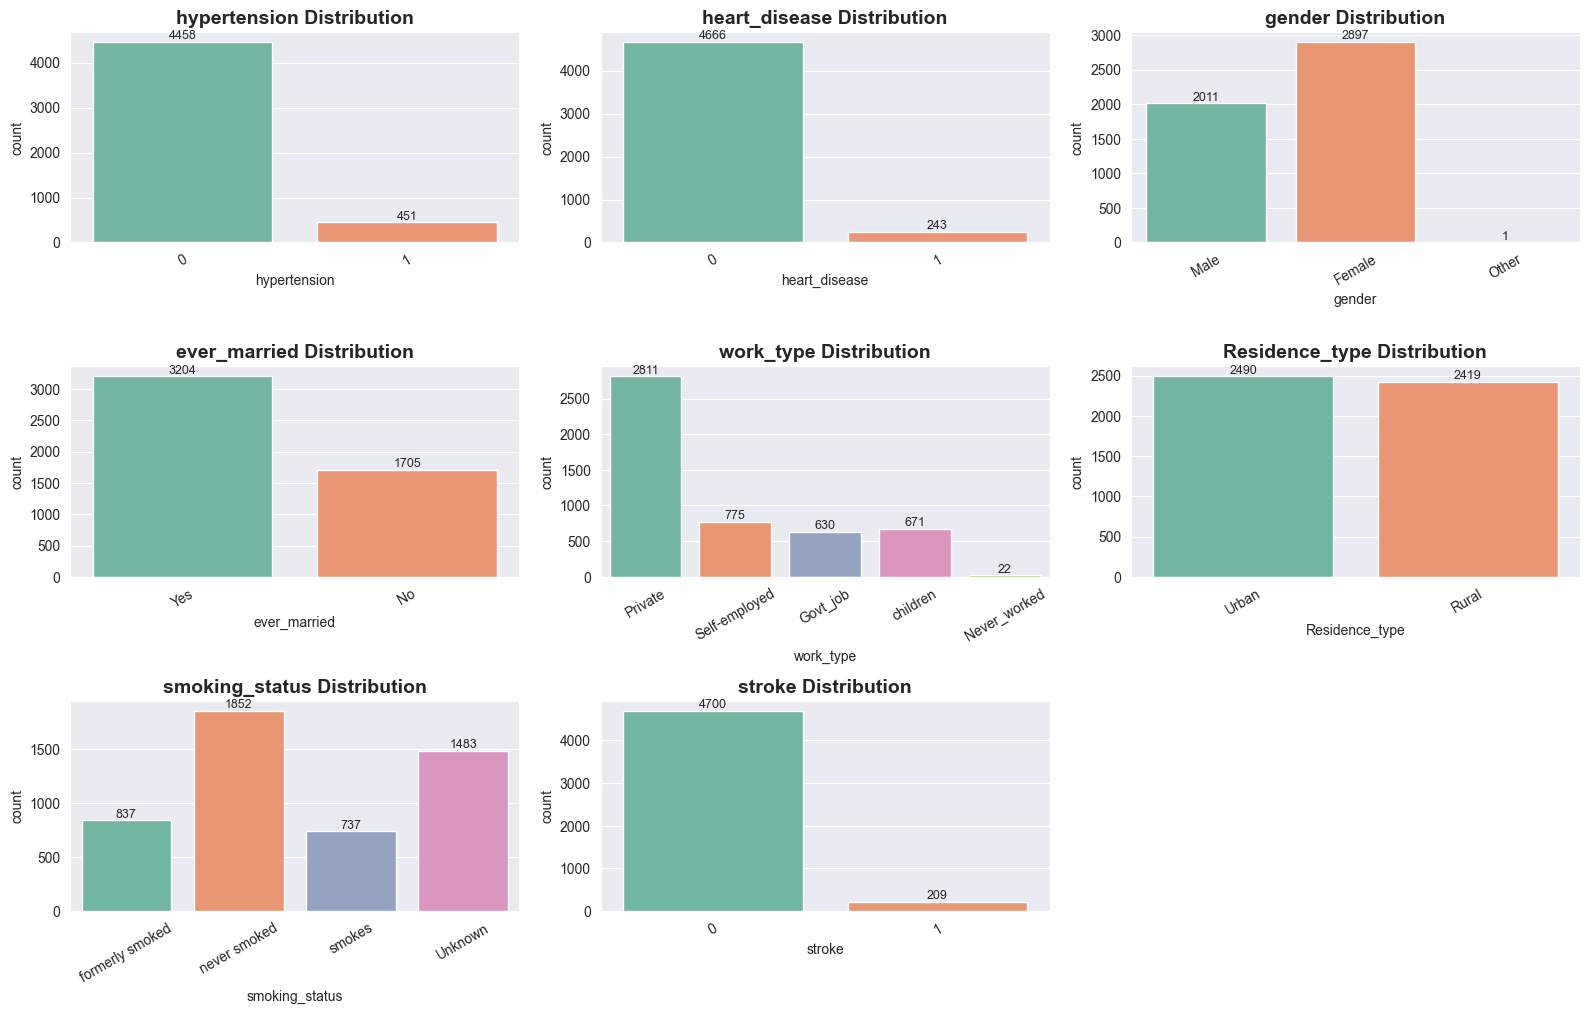

In [21]:
cols_for_count = ['hypertension','heart_disease','gender','ever_married','work_type','Residence_type','smoking_status','stroke']

sns.set_style('darkgrid')
fig , axes = plt.subplots(5,3,figsize=( 16,16))

axes = axes.flatten()

for i , col in enumerate(cols_for_count):
    ax = sns.countplot(
        data = df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=14, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)

if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()